# 0. Imports

In [1]:
!pip install umap-learn shap catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [2]:
# Sistema
import os
import zipfile

# Principais imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import datetime
# from google.colab import drive
# drive.mount('/content/drive')

# Classificadores
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Arvore de Decisao
from sklearn.ensemble import RandomForestClassifier # Floresta de Decisao
from sklearn.svm import SVC # Support Vector Machine
from xgboost import XGBClassifier # XGBoost
from lightgbm import LGBMClassifier # LGBM
from sklearn.svm import LinearSVC # Linear Support Vector Machine
from sklearn.dummy import DummyClassifier # Classificador aleatorio
from catboost import CatBoostClassifier # CatBoost
from sklearn.linear_model import LogisticRegression # Regressao Logistica

# Clustering
from sklearn.cluster import KMeans

# Avaliadores
from sklearn.metrics import classification_report # Acc, Precision, Recall e F1-Score
from sklearn.metrics import ConfusionMatrixDisplay # Matriz de confusao
from sklearn.metrics import roc_auc_score # area sob curva roc
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, accuracy_score # Metricas
from sklearn.model_selection import cross_val_score # CrossValidation com uma metrica
from sklearn.model_selection import cross_validate # CrossValidation com mais de uma metrica

# Pre processamento
from sklearn.preprocessing import StandardScaler # Normaliza feature media = 0 e desvpad = 1
from sklearn.preprocessing import OneHotEncoder # Encoda uma coluna categorica
from sklearn.impute import SimpleImputer # Imputer: Preenche uma determinada feature
from imblearn.over_sampling import SMOTE # SMOTE

# Datasets nativos SKLearn
from sklearn.datasets import load_digits # Digitos Manuscritos

# DeepLearning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Utilidades
from sklearn.pipeline import make_pipeline # Cria pipeline
from sklearn.pipeline import Pipeline # Executa um pipeline
from sklearn.compose import ColumnTransformer # Aplica transformacoes em colunas
from sklearn.model_selection import train_test_split # Separa treino e teste
from sklearn.model_selection import StratifiedKFold # Estratifica os dados igualmente
from sklearn.model_selection import GridSearchCV # Busca exaustiva
from sklearn.model_selection import RandomizedSearchCV # Busca exaustiva aleatória
from sklearn.manifold import TSNE # TSNE visualização de clusters
import umap # umap visualização de clusters
import shap
from sklearn.decomposition import PCA # Redução de dimensionalidade
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load Data

In [3]:
# Load  MNIST
mnist = keras.datasets.mnist

cifar = keras.datasets.cifar100

# 2. Data Exploration

## 2.1. MNIST

In [4]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


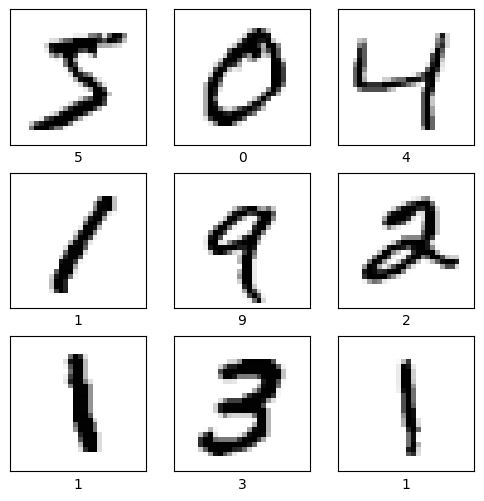

In [5]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

In [6]:
print(f'Shape matriz de treino: {train_images.shape}')
print(f'Shape matriz de teste: {test_images.shape}')

Shape matriz de treino: (60000, 28, 28)
Shape matriz de teste: (10000, 28, 28)


In [7]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [8]:
# Normalizando as matrizes

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

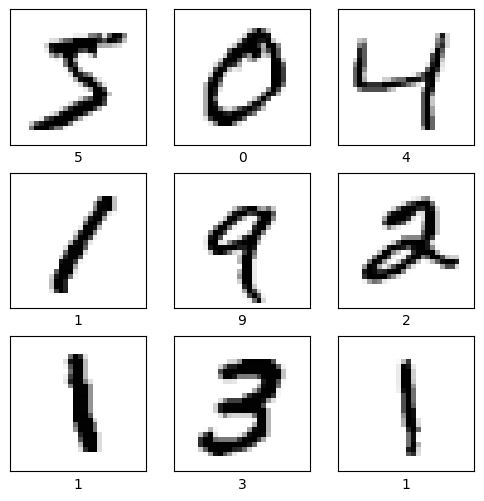

In [9]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

## 2.2. CIFAR100

In [10]:
(train_images, train_labels), (test_images, test_labels) = cifar.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


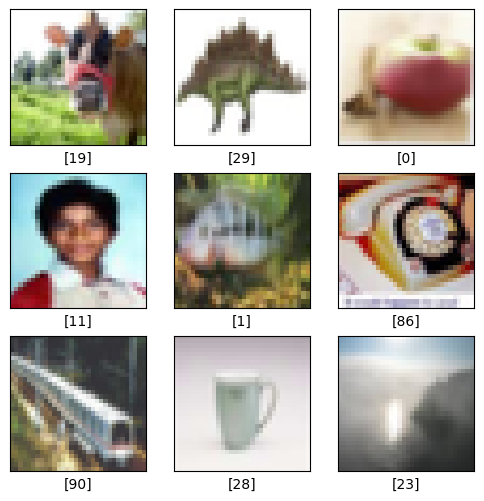

In [11]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

In [12]:
# Diferente do MNIST, agora temos imagens coloridas em 32x32 e com 3 canais (RGB!)
print(f'Shape matriz de treino: {train_images.shape}')
print(f'Shape matriz de teste: {test_images.shape}')

Shape matriz de treino: (50000, 32, 32, 3)
Shape matriz de teste: (10000, 32, 32, 3)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [195, 205, 193],
        [212, 224, 204],
        [182, 194, 167]],

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [170, 176, 150],
        [161, 168, 130],
        [146, 154, 113]],

       [[255, 255, 255],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [189, 199, 169],
        [166, 178, 130],
        [121, 133,  87]],

       ...,

       [[148, 185,  79],
        [142, 182,  57],
        [140, 179,  60],
        ...,
        [ 30,  17,   1],
        [ 65,  62,  15],
        [ 76,  77,  20]],

       [[122, 157,  66],
        [120, 155,  58],
        [126, 160,  71],
        ...,
        [ 22,  16,   3],
        [ 97, 112,  56],
        [141, 161,  87]],

       [[ 87, 122,  41],
        [ 88, 122,  39],
        [101, 134,  56],
        ...,
        [ 34,  36,  10],
        [105, 133,  59],
        [138, 173,  79]]], dtype=uint8)
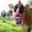

In [13]:
train_images[0]

In [14]:
# Normalizando as matrizes

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

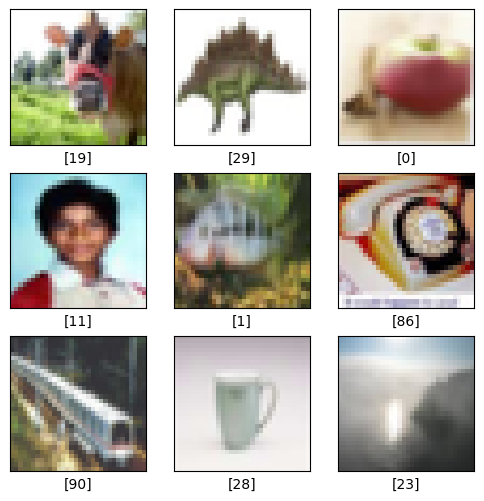

In [15]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

# 3. Modelos de Redes Neurais

## 3.1. MLP (Multi Layer Perceptron)

### 3.1.1. MLP MNIST

In [16]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

In [17]:
#   O MLP é um modelo totalmente conectado, isso significa que todos os neurônios de entrada são utilizados como
# input para os neurônios nas camadas ocultas
#   No modelos mais simples possível (camada de input, oculta e output), o modelo receberá como input 28*28 = 784

model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape = (28, 28)), # Camada de input: Flatten - transforma a matriz 28*28 em um vetor de 784 dimensoes
    keras.layers.Dense(128, activation = tf.nn.relu), # Camada oculta: 128 neurônios e função de ativação relu
    keras.layers.Dense(10, activation = tf.nn.softmax) # Camada de Output: 10 neurônios e função de ativação softmax
])

model_mlp.compile(loss = 'sparse_categorical_crossentropy', # sparse_categorical pois a saida (train_label) é sparsa (UMA coluna de 0 a 9)
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model_mlp.fit(train_images, train_labels, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9251 - loss: 0.2568
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9661 - loss: 0.1171
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9754 - loss: 0.0844
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9809 - loss: 0.0668
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9834 - loss: 0.0564
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0484
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9879 - loss: 0.0412
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9900 - loss: 0.0349
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9910 - loss: 0.0310
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0273


In [20]:
test_loss, test_acc = model_mlp.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9776 - loss: 0.0924
 Loss no teste: 0.09244620054960251 
 Accuracy no teste: 0.9775999784469604


### 3.1.2. MLP CIFAR100

In [21]:
(train_images, train_labels), (test_images, test_labels) = cifar.load_data()

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

In [22]:
#   O MLP é um modelo totalmente conectado, isso significa que todos os neurônios de entrada são utilizados como
# input para os neurônios nas camadas ocultas
#   No modelos mais simples possível (camada de input, oculta e output), o modelo receberá como input 28*28 = 784

model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape = (32, 32, 3)), # Camada de input: Flatten - transforma a matriz 28*28 em um vetor de 784 dimensoes
    keras.layers.Dense(256, activation = tf.nn.relu), # Camada oculta: 256 neurônios e função de ativação relu
    keras.layers.Dense(100, activation = tf.nn.softmax) # Camada de Output: 100 neurônios e função de ativação softmax
])

model_mlp.compile(loss = 'sparse_categorical_crossentropy', # sparse_categorical pois a saida (train_label) é sparsa (UMA coluna de 0 a 9)
                  metrics = ['accuracy'])

In [23]:
model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,388 (3.10 MB)

 Trainable params: 812,388 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model_mlp.fit(train_images, train_labels, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0556 - loss: 4.2233
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1038 - loss: 3.9118
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1173 - loss: 3.8420
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1234 - loss: 3.8187
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1259 - loss: 3.8041
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1274 - loss: 3.8024
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1277 - loss: 3.8065
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1306 - loss: 3.8066
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1279 - loss: 3.8204
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1279 - loss: 3.8322


In [25]:
test_loss, test_acc = model_mlp.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1323 - loss: 3.8501
 Loss no teste: 3.8501386642456055 
 Accuracy no teste: 0.13230000436306


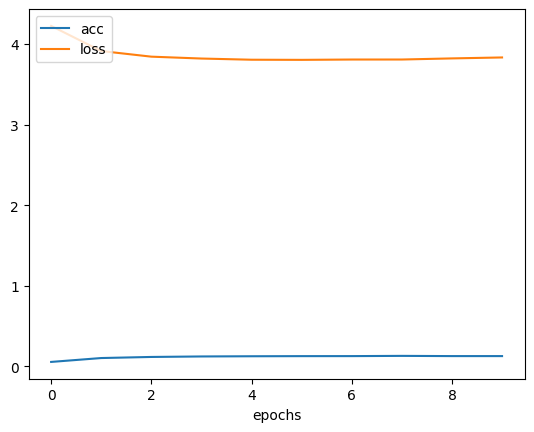

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.legend(['acc', 'loss'], loc = 'upper left')
plt.show()

## 3.2. CNN (Convolutional Neural Network)

## 3.2.1. CNN com Flatten + Dense

In [46]:
model_cnn = keras.Sequential()

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 32, # 32 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same',
                                  activation = 'relu', # Função de ativação
                                  input_shape = (32, 32, 3) # Dimensões do input
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 64,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 128,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 256,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

model_cnn.add(keras.layers.Flatten())
model_cnn.add(keras.layers.Dense(1024, activation = 'relu'))
model_cnn.add(keras.layers.Dropout(0.2))
model_cnn.add(keras.layers.Dense(512, activation = 'relu'))
model_cnn.add(keras.layers.Dropout(0.2))
model_cnn.add(keras.layers.Dense(100, activation = 'softmax'))

model_cnn.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])
model_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,705,700 (10.32 MB)

 Trainable params: 2,704,740 (10.32 MB)

 Non-trainable params: 960 (3.75 KB)

In [51]:
history = model_cnn.fit(train_images,
                        train_labels,
                        epochs = 10,
                        validation_split = 0.25)

test_loss, test_acc = model_cnn.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4390 - loss: 2.0864 - val_accuracy: 0.3782 - val_loss: 2.4853
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4517 - loss: 2.0025 - val_accuracy: 0.4043 - val_loss: 2.3684
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4723 - loss: 1.9326 - val_accuracy: 0.4173 - val_loss: 2.3148
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4927 - loss: 1.8378 - val_accuracy: 0.4174 - val_loss: 2.3293
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5050 - loss: 1.7786 - val_accuracy: 0.4139 - val_loss: 2.3482
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5238 - loss: 1.6996 - val_accuracy: 0.3510 - val_loss: 2.9222
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5370 - loss: 1.6473 - val_accuracy: 0.4231 - val_loss: 2.3754
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5545 - loss: 1.583

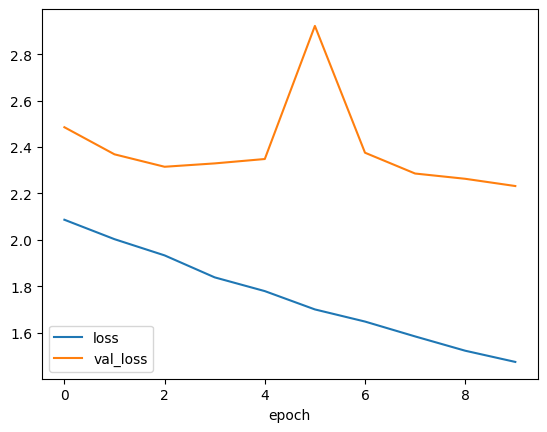

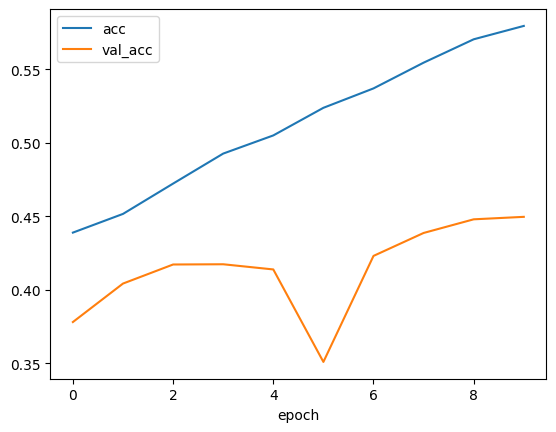

In [52]:
# Mostrar graficamente

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='lower left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.legend(['acc', 'val_acc'], loc='upper left')
plt.show()

## 3.2.2. CNN com GlobalAveragePooling2D()

In [53]:
model_cnn = keras.Sequential()

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 32, # 32 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same',
                                  activation = 'relu', # Função de ativação
                                  input_shape = (32, 32, 3) # Dimensões do input
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 64,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 128,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 256,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

model_cnn.add(keras.layers.GlobalAveragePooling2D())

model_cnn.add(keras.layers.Dense(100,activation="softmax"))

model_cnn.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])
model_cnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105,700 (4.22 MB)

 Trainable params: 1,104,740 (4.21 MB)

 Non-trainable params: 960 (3.75 KB)

In [54]:
history2 = model_cnn.fit(train_images,
                        train_labels,
                        epochs = 10,
                        validation_split = 0.25)

test_loss2, test_acc2 = model_cnn.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.1634 - loss: 3.5701 - val_accuracy: 0.1886 - val_loss: 3.4821
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.2952 - loss: 2.8109 - val_accuracy: 0.2658 - val_loss: 3.0821
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3740 - loss: 2.4366 - val_accuracy: 0.3318 - val_loss: 2.6783
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4287 - loss: 2.1780 - val_accuracy: 0.2630 - val_loss: 3.3695
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4668 - loss: 1.9881 - val_accuracy: 0.4054 - val_loss: 2.3365
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5082 - loss: 1.8088 - val_accuracy: 0.4235 - val_loss: 2.3128
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5447 - loss: 1.6596 - val_accuracy: 0.4190 - val_loss: 2.3630
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5726 - loss: 1.53

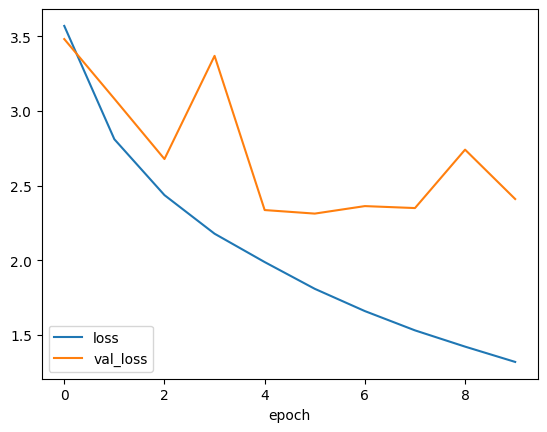

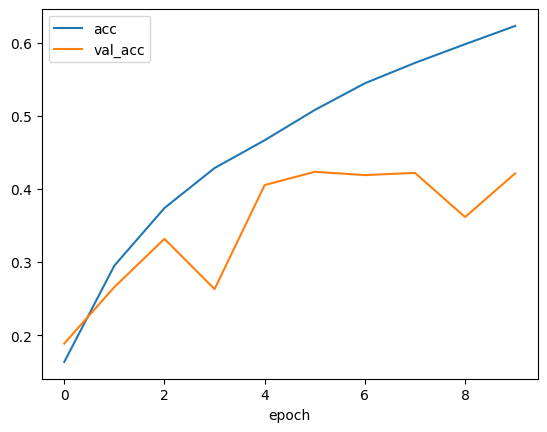

In [55]:
# Mostrar graficamente

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='lower left')
plt.show()

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('epoch')
plt.legend(['acc', 'val_acc'], loc='upper left')
plt.show()

In [ ]:
def def_model_cnn():
    model = keras.Sequential()

    # --------------------- Camada de Convolução --------------------- #
    # Convolução
    model.add(keras.layers.Conv2D(filters = 32, # 32 filtros/kernels
                                    kernel_size = 5, # Dimensões do filtro/kernel
                                    padding = 'same',
                                    activation = 'relu', # Função de ativação
                                    input_shape = (32, 32, 3) # Dimensões do input
                                    ))
    # Normalização
    model.add(keras.layers.BatchNormalization())
    # Pooling
    model.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                            strides = 2))
    # Dropout
    model.add(keras.layers.Dropout(0.2))

    # --------------------- Camada de Convolução --------------------- #
    # Convolução
    model.add(keras.layers.Conv2D(filters = 64,
                                    kernel_size = 5,
                                    padding = 'same',
                                    activation = 'relu'
                                    ))
    # Normalização
    model.add(keras.layers.BatchNormalization())
    # Pooling
    model.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                            strides = 2))
    # Dropout
    model.add(keras.layers.Dropout(0.2))

    # --------------------- Camada de Convolução --------------------- #
    # Convolução
    model.add(keras.layers.Conv2D(filters = 128,
                                    kernel_size = 5,
                                    padding = 'same',
                                    activation = 'relu'
                                    ))
    # Normalização
    model.add(keras.layers.BatchNormalization())
    # Pooling
    model.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                            strides = 2))
    # Dropout
    model.add(keras.layers.Dropout(0.2))

    # --------------------- Camada de Convolução --------------------- #
    # Convolução
    model.add(keras.layers.Conv2D(filters = 256,
                                    kernel_size = 5,
                                    padding = 'same',
                                    activation = 'relu'
                                    ))
    # Normalização
    model.add(keras.layers.BatchNormalization())
    # Pooling
    model.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                            strides = 2))
    # Dropout
    model.add(keras.layers.Dropout(0.2))

    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dense(100,activation="softmax"))

    model.compile(optimizer = 'adam',
                    loss = 'sparse_categorical_crossentropy',
                    metrics = ['accuracy'])
    model.summary()

    return model